# Stellar Population Synthesis (SPS) Modeling of Galaxies

In this notebook, you will become familiar with **stellar population synthesis (SPS)** models and how they can be used to derive important galaxy properties such as stellar masses!

Run the cell below to import some pre-written module functions that will help with the analysis

In [84]:
import numpy as np                 # for math !
import matplotlib.pyplot as plt    # for plotting !
import pandas as pd                # for data manipulation !
import os                          # universal os

import warnings                    # ... ignore warnings
warnings.filterwarnings('ignore')

## Loading SSP models

You will load data from the `bc03_models.txt` file, which originates from work done by Bruzual & Charlot (2003). 

This data contains **simple stellar population (SSP)** models. A single SSP model represents a cluster of stars formed instantaneously at age = 0 Myr, with a distribution of stellar mass following an assumed initial mass function. As an SSP ages (age = 1 Myr, age = 10 Myr, age = 100 Myr, etc...) the spectrum it produces changes. 

Run the cell below to save the data as a variable and display it. 

In [2]:
# defining the column names for this data
col_names = ["WAVE", "LUM1", "LUM10", "LUM100", "LUM1000", "LUM5000", "LUM10000"]

# using Pandas function to convert data in the text file into a table format
SSP_table = pd.read_csv("data/bc03_models.txt", delim_whitespace=True, comment="#", names=col_names, header=None)
SSP_table

,WAVE,LUM1,LUM10,LUM100,LUM1000,LUM5000,LUM10000
0,3400.00,0.031278,0.012009,0.001045,0.000109,0.000014,0.000007
1,3400.78,0.031121,0.012052,0.001022,0.000108,0.000014,0.000007
2,3401.57,0.031252,0.012263,0.001013,0.000104,0.000014,0.000007
3,3402.35,0.031369,0.012384,0.001011,0.000100,0.000014,0.000006
4,3403.13,0.031347,0.012337,0.001012,0.000096,0.000013,0.000006
...,...,...,...,...,...,...,...
4766,10187.80,0.000657,0.002418,0.000249,0.000088,0.000030,0.000019
4767,10190.10,0.000656,0.002418,0.000249,0.000088,0.000030,0.000019
4768,10192.50,0.000655,0.002418,0.000248,0.000088,0.000030,0.000019
4769,10194.80,0.000655,0.002418,0.000248,0.000088,0.000030,0.000019


If you get an error, make sure you have a `data` directory at the same level as this Jupyter Notebook, containing the `bc03_models.txt` file !

Otherwise, you should get a table. 

The columns are:
- `WAVE` : wavelengths in units of Angstroms [Å]
- `LUM1` : luminosity at given `WAVE` value for an SSP with age = 1 Myr, in units of solar lum per Angstrm [L_☉ / Å]
- `LUM10` :                    ''                      age = 10 Myr                ''
- `LUM100` :                   ''                      age = 100 Myr               ''
- `LUM1000` :                  ''                      age = 1000 Myr              ''
- `LUM5000` :                  ''                      age = 5000 Myr              ''
- `LUM10000` :                 ''                      age = 10000 Myr             ''

## Visualizing SSP models

Let's see what this data looks like! 

Below, we set up *most* of the code to plot the spectrum (`LUM` vs. `WAVE`) of each SSP model onto a single figure. Be sure to replace the `?` placeholders throughout code with your best guesses. Refer to the comments for hints !

In [3]:
# defining the SSP model column names
# we will use this in our "for loop" below
lum_column_names = col_names[1:]  # slicing the luminosity ("LUM") columns from our original col_names list
lum_column_names                  # displaying these column names below

['LUM1', 'LUM10', 'LUM100', 'LUM1000', 'LUM5000', 'LUM10000']

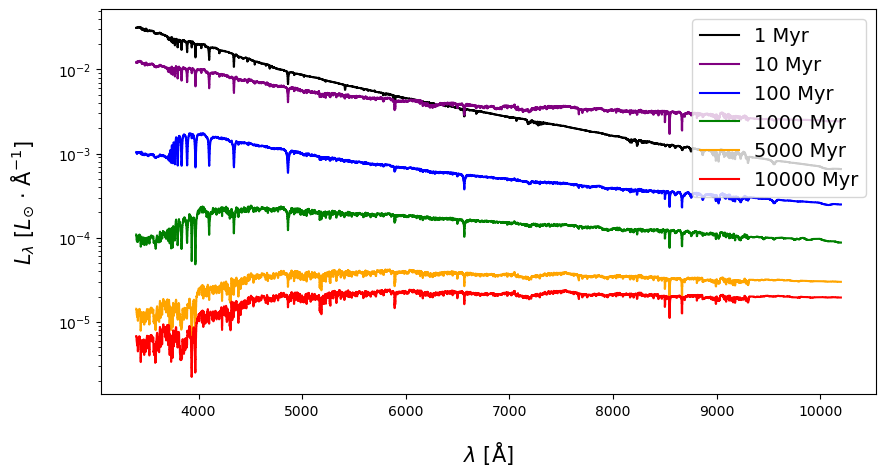

In [5]:
# defining a list of colors and labels for plotting each SSP model
color_list1 = ['black','purple','blue','green','orange','red']
label_list = ['1 Myr','10 Myr','100 Myr','1000 Myr','5000 Myr','10000 Myr']

# initializing the figure
plt.figure(figsize=(10,5))

# adding labels for the axes
plt.xlabel(r'$\lambda$ [$\rm{\AA}$]', fontsize=15, labelpad=15)
plt.ylabel(r'$L_{\lambda}$ [$L_{\odot}$ $\cdot$ $\rm{\AA}^{-1}$]', fontsize=15, labelpad=15)

# looping through the SSP model column names
# in each iteration:
#       i is an indexing variable (from 0 to 5)
#       lum_column_names_i is the ith element in our list "lum_column_names"
for i, lum_column_names_i in enumerate(lum_column_names):

    # wavelength values for the current SSP model
    wavelengths = SSP_table['WAVE']
    
    # luminosity values for the current SSP model
    # ~~~~~~~~~ REPLACE "?" WITH YOUR CODE ~~~~~~~~~
    luminosities = SSP_table[?]    
    # ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
    
    # plotting the current spectrum (luminosity vs. wavelength)
    # ~~~~~~~~~ REPLACE "?" WITH YOUR CODE ~~~~~~~~~
    plt.step(x=?, y=?, where='mid', color=color_list1[i], label=label_list[i]) 
    # ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~

# setting a legend for the figure
plt.legend(fontsize=14, loc='upper right')
# setting the y-axis to be in log scale, since there are enormous variations in luminosity among the SSP models
plt.yscale('log')
# saving and displaying figure
fig_name = 'SSP_model_spectra.png'
file_path = os.path.join('plots', fig_name)
plt.savefig(file_path, dpi=500, bbox_inches='tight')
plt.show()

Reflect on the figure above. Recall that each colored curve represents an SSP observed at a given age.

As an SSP ages:  
- the overall spectral luminosity decreases
- the luminosity at bluer/shorter wavelengths decreases
- the spectral slope becomes more positive
- at ages >= 100 Myr, there is a dramatic drop in luminosity around 4,000 Å. This is called the "4,000 Å Break".

This can be explained by our understanding of stellar evolution. Massive stars emit light at bluer/shorter wavelengths and die off quicker than low-mass stars.

## Dust attenuated SSP models

Now, we will explore the impact of interstellar dust attenutation on galaxy spectra.

We provide the functional forms for this in the code block below. Read the function descriptions for more information.

In [6]:
def attenuation_law(v_band_optical_depth, wavelength):
    '''
    Dust attenuation law from Charlot & Fall (2000)

    args:
        v_band_optical_depth (float): 𝜏_V --> the V-band optical depth
        wavelength (float): λ --> wavelength in Angstroms [Å]

    returns (float): 𝜏(λ) --> optical depth at a given wavelength
    '''
    
    optical_depth_at_wav = v_band_optical_depth * (wavelength / 5000)**(-0.7)
    
    return optical_depth_at_wav

def lum_apply_dust(int_luminosity, optical_depth_at_wav):
    '''
    Computes a dusty (observed) spectrum of a dust-corrected (intrinsic) luminosity of a spectrum given an optical depth
    
    args:
        int_luminosity (float): L(λ)_0 --> intrinsic luminosity at a given wavelength
        optical_depth_at_wav (float): 𝜏(λ) --> optical depth at a given wavelength

    returns: obs_luminosity (float): L(λ)_dusty --> observed luminosity at a given wavelength
    '''
    
    obs_luminosity = int_luminosity * np.exp(-optical_depth_at_wav)
    
    return obs_luminosity

Since these SSP spectra are models, their luminosities are not dust attenuated. For the 1 Myr old SSP, we want to apply these functions to add in various amounts of dust to our observations. 

In the code block below, replace the `?` placeholders.

In [7]:
# we provide different 𝜏_V values to examine the effect of various amounts of dust
v_band_optical_depth_vals = [0, 0.5, 1, 2]

# initializing a list of dust-attenuated luminosity values
observed_lum_1_Myr_list = []

# looping through our optical depth list
for optical_depth in v_band_optical_depth_vals:

    # wavlength and luminosity values for the 1 Myr old SSP
    wavelength_values = SSP_table['WAVE']
    lum1_values = SSP_table['LUM1']

    # computing the optical depth at a given wavelength
    # (hint: look at how we defined this function in the above cell)
    # ~~~~~~~~~ REPLACE "?" WITH YOUR CODE ~~~~~~~~~
    optical_depth_at_wav = attenuation_law(?, wavelength_values) 
    # ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~

    # computing the dusty SSP
    # (hint: look at how we defined this function in the above cell)
    # ~~~~~~~~~ REPLACE "?" WITH YOUR CODE ~~~~~~~~~
    obs_luminosity_1_Myr = lum_apply_dust(lum1_values, ?) 
    # ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~

    # adding this dusty SSP to our list
    observed_lum_1_Myr_list.append(obs_luminosity_1_Myr)
    
# displaying the length of our list of dust-attenuated SSPs that are 1 Myr old
# this list should contain 4 dusty SSPs (one for each 𝜏_V value)
len(observed_lum_1_Myr_list)

4

Now, let's visualize these dusty SSPs!

Similar to before, we loop through a list of SSPs and plot a curve for each one onto a single figure. Be sure to replace the `?` placeholders throughout code with your best guesses. Refer to the comments for hints !

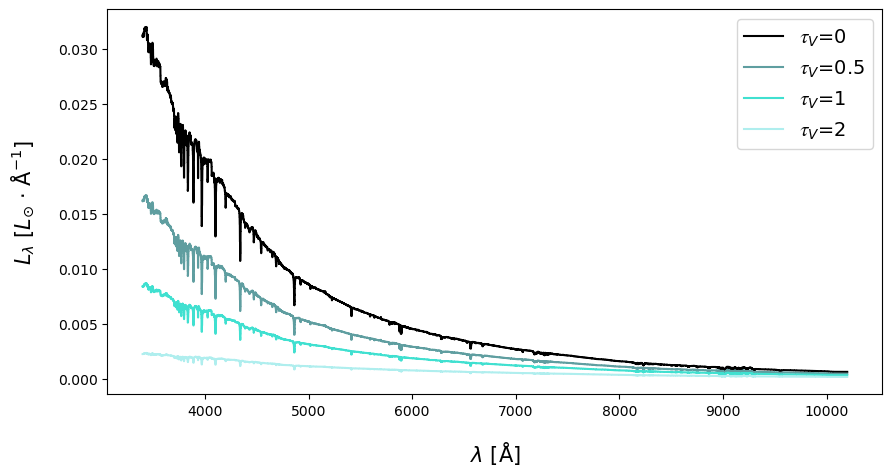

In [8]:
# defining a list of colors for plotting each dust-attenuated SSP
color_list2 = ['black','cadetblue','turquoise','paleturquoise']

# initializing the figure
plt.figure(figsize=(10,5))

# adding labels for the axes
plt.xlabel(r'$\lambda$ [$\rm{\AA}$]', fontsize=15, labelpad=15)
plt.ylabel(r'$L_{\lambda}$ [$L_{\odot}$ $\cdot$ $\rm{\AA}^{-1}$]', fontsize=15, labelpad=15)

# looping through the dust-attenuatted SSP models we generated
# in each iteration:
#       i is an indexing variable (from 0 to 3)
#       observed_lum_1_Myr is the ith element in our list "observed_lum_1_Myr_list"
for i, observed_lum_1_Myr in enumerate(observed_lum_1_Myr_list):

    # wavelength values for the current SSP model
    wavelengths = SSP_table['WAVE']

    # plotting the current spectrum (luminosity vs. wavelength)
    # ~~~~~~~~~ REPLACE "?" WITH YOUR CODE ~~~~~~~~~
    plt.step(?, ?, where='mid', color=color_list2[i], label='$𝜏_V$='+str(v_band_optical_depth_vals[i])) 
    # ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~

# setting a legend for the figure
plt.legend(fontsize=14,loc='upper right')
# saving and displaying figure
fig_name = 'SSP_models_dust_attenuated.png'
file_path = os.path.join('plots', fig_name)
plt.savefig(file_path, dpi=500, bbox_inches='tight')
plt.show()

Reflect on the figure above. Note that 𝜏_V = 0 is the same as our intrinsic SSP model spectrum (with no dust).

We see that dust attenuates A LOT of the spectrum at bluer/shorter wavelengths!

## Fitting a real galaxy spectrum with these SSP models !

The stars that make up galaxies do not form instantaneously. Thus, galaxies are made up of some combination of simple stellar populations (SSPs) and the observed galaxy spectrum can be modeled.

You will load data from the `manga_7443-6102.txt` file - which contains the spectrum of an SDSS-IV MaNGA galaxy - and try your hand at stellar population synthesis (SPS) modeling the galaxy !

Run the cell below to save the data as a variable and display it. 

In [9]:
# defining the column names for this data
col_names2 = ["WAVE", "LUM"]

# using Pandas function to convert data in the text file into a table format
obs_galaxy_table = pd.read_csv("data/manga_7443-6102.txt", delim_whitespace=True, comment="#", names=col_names2, header=None)

# converting luminosity units to be in [L_☉ / Å]
obs_galaxy_table['LUM'] = obs_galaxy_table['LUM'] * 10**6 
obs_galaxy_table

,WAVE,LUM
0,3600.0364,1420621.8
1,3600.8654,1327084.3
2,3601.6946,1247722.0
3,3602.5240,1363592.8
4,3603.3536,1308909.6
...,...,...
3975,8990.9770,1692580.4
3976,8993.0475,1705480.1
3977,8995.1184,1688129.8
3978,8997.1899,1669644.9


If you get an error, make sure the `manga_7443-6102.txt` file is in the same directory as this Jupyter Notebook !

Otherwise, you should get a table. 

The columns are:
- `WAVE` : wavelengths in units of Angstroms [Å]
- `LUM` : galaxy luminosity at given `WAVE` value in units of solar lum per Angstrm [L_☉ / Å]

The galaxy spectrum is a linear combination of our SSP models. We provide the *most* of the functional form for this in the code block below. Read the function description for more information and replace the `?` placeholders.

In [11]:
def spectrum_model(wavelengths, L1, L100, L1000, L10000, v_band_optical_depth, c_vals):
    '''
    modeling an observed galaxy spectrum as a linear combination of SSP models

    args:
        wavelengths (list): λ --> wavelength in Angstroms [Å]
        L1 (list): L_0 --> intrinsic luminosity of 1 Myr SSP model
        L10 (list): L_0 -->          ''            10 Myr SSP model
        L1000 (list): L_0 -->        ''            1000 Myr SSP model
        L10000 (list): L_0 -->       ''            10000 Myr SSP model
        v_band_optical_depth (float): 𝜏_V --> the V-band optical depth
        c_vals (list): coefficient values 

    returns (tuple): the galaxy model spectrum, along with the contribution of each SSP model to this galaxy spectrum
    '''

    # unpacking the coefficient values (these are picked by you!)
    c1, c2, c3, c4, c5 = c_vals

    # computing the optical depth across all wavelengths (the input for this calculation is picked by you!)
    optical_depth = attenuation_law(v_band_optical_depth, wavelengths)

    # SSP models adjusted with dust attenutaion and coefficient values
    # c1 - c4 are adjusting the contribution of each SSP model
    # c5 adjusts the contribution of the dust attenuation (thus it scales the whole spectrum)
    model1_spec = c1 * (c5 * lum_apply_dust(L1, optical_depth))
    model100_spec  = c2 * (c5 * lum_apply_dust(L100, optical_depth))
    model1000_spec  = c3 * (c5 * lum_apply_dust(L1000, optical_depth))
    model10000_spec  = c4 * (c5 * lum_apply_dust(L10000, optical_depth))

    # our galaxy model spectrum is a summation of these SSP model spectra
    # ~~~~~~~~~ REPLACE "?" WITH YOUR CODE ~~~~~~~~~
    galaxy_model_spectrum = ? + ? + ? + ?
    # ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~

    # packing up the model spectra into a list
    model_spectra = [model1_spec, model100_spec, model1000_spec, model10000_spec]

    return galaxy_model_spectrum , model_spectra 

Now, let's call this function. `c1`-`c5` and `v_band_optical_depth` are constants that you will determine by experimentation. You can set these in the cell below by replacing `?` with numerical values. At first, you will take a blind guess. After running the two cells below, look at how well your model fits the data and adjust one of the constants. Run the cells again and see how the model changes. Keep doing this until you get a good fit to the observed galaxy spectrum.

In practice, astronomers use a minimization routine. But doing it by hand, you can get a feel for the degeneracies in SPS modeling. In other words, adjusting one of the constants can have the same effect as adjusting another constant. This makes it harder to pinpoint the galaxy's true stellar population, and therefore its properties (e.g., old, metal-poor and young, metal-rich galaxy spectra can appear the same).

In [79]:
# ~~~~~~~~~ REPLACE "?" WITH YOUR CODE ~~~~~~~~~
c_vals = [10**?, 10**?, 10**?, 10**?, 10**?]   # ... I recommend setting these constants to some power of ten (maybe between 1 and 10)
v_band_optical_depth = ?                       # ... optical depth ranges between 0 and 2
# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~

# passing values into the galaxy spectrum model function (right-hand side) and unpacking the results (left-hand side)
galaxy_model_luminosity, model_luminosities = spectrum_model(SSP_table['WAVE'],         # wavelengths
                                                             SSP_table['LUM1'],         # luminosities of each SSP
                                                             SSP_table['LUM100'],       # ''
                                                             SSP_table['LUM1000'],      # ''
                                                             SSP_table['LUM10000'],     # ''
                                                             v_band_optical_depth,      # optical depth value (that you picked)
                                                             c_vals                     # coefficient values  (that you picked)
                                                            )

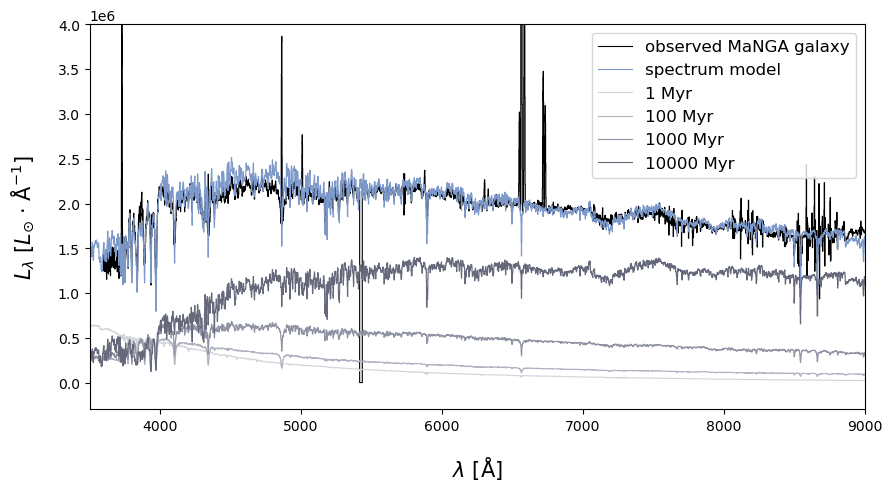

In [104]:
# defining a list of colors and labels for plotting each SSP model
colors3 = ['#D2D4DB','#B0B3BF','#8F93A3', '#65697B']
labs3 = ['1 Myr','100 Myr','1000 Myr','10000 Myr']

# initializing the figure
plt.figure(figsize=(10,5))
# adding labels for the axes
plt.xlabel(r'$\lambda$ [$\rm{\AA}$]', fontsize=15, labelpad=15)
plt.ylabel(r'$L_{\lambda}$ [$L_{\odot}$ $\cdot$ $\rm{\AA}^{-1}$]', fontsize=15, labelpad=15)

# ----------------------- PLOTTING OBSERVED GALAXY SPECTRUM -----------------------
# wavelength values for the observed galaxy from SDSS-IV MaNGA
wavelengths = obs_galaxy_table['WAVE']

# luminosity values for the observed galaxy from SDSS-IV MaNGA
luminosities = obs_galaxy_table['LUM']

# plotting the observed galaxy spectrum (luminosity vs. wavelength)
# ~~~~~~~~~ REPLACE "?" WITH YOUR CODE ~~~~~~~~~
plt.step(?, ?, where='mid', color='black', linewidth=0.8, label='observed MaNGA galaxy')
# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~

# ------------------------- PLOTTING GALAXY MODEL SPECTRUM -------------------------

# wavelength values for the SSP models
spec_model_wavs = SSP_table['WAVE']

# plotting the model galaxy spectrum (luminosity vs. wavelength)
plt.step(spec_model_wavs, galaxy_model_luminosity, where='mid', color='#7D99CA', linewidth=0.8, label='spectrum model') 

# ----------------- PLOTTING SSPs THAT MAKES UP THE MODEL SPECTRUM -----------------

# looping through the dust-attenuatted SSP models we generated
# in each iteration:
#       i is an indexing variable (from 0 to 3)
#       model_luminosity is the ith element in our list "model_luminosities"
for i, model_luminosity in enumerate(model_luminosities):

    # plot the SSP models that make up this best-fit spectrum (luminosity vs. wavelength)
    # ~~~~~~~~~ REPLACE "?" WITH YOUR CODE ~~~~~~~~~
    plt.step(spec_model_wavs, ?, where='mid', color=colors3[i], linewidth=0.8, label=labs3[i]) 
    # ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~

# -----------------------------------------------------------------------------------

# adjusting limits on x- and y-axis
plt.ylim(-0.03e7, 0.4e7)
plt.xlim(3500,9000)
# setting a legend for the figure
plt.legend(fontsize=12,loc='upper right')
# saving and displaying figure
fig_name = 'SPS_result.png'
file_path = os.path.join('plots', fig_name)
plt.savefig(file_path, dpi=500, bbox_inches='tight')
plt.show()

Don't worry about fitting the emission lines in the observed spectrum. Your model should fit the galaxy continuum and absorption features only.

## Computing the galaxy's stellar mass

Once you're happy with your fit, we can compute the galaxy's stellar mass !

This formula is given below, in which the galaxy's stellar mass equals the sum of the constants `c1`-`c4` (coefficients for each SSP) multiplied by `c5` (the scaling coefficient).

In [81]:
# unpacking our constants from the list
c1, c2, c3, c4, c5 = c_vals  

# computing the observed galaxy's stellar mass based on our best-fit model
galaxy_stellar_mass = (c1 + c2 + c3 + c4) * c5

# displaying this value
print('This observed MaNGA galaxy has a stellar mass of', round(galaxy_stellar_mass,2), 'solar masses')

This observed MaNGA galaxy has a stellar mass of 66599358738.52 solar masses


It's hard to interpret this value without a familiar comparison. Let's compare it to our Milky Way Galaxy's stellar mass:

In [82]:
# measure mass of our Milky Way Galaxy
milky_way_stellar_mass = 9.6e10  # [solar masses]

# taking the ratio of the Milky Way Galaxy's stellar mass to our galaxy's measured stellar mass 
ratio = milky_way_stellar_mass / galaxy_stellar_mass

# displaying the ratio 
print('The Milky Way Galaxy is', round(ratio,2), 'times more massive than this observed MaNGA galaxy')

The Milky Way Galaxy is 1.44 times more massive than this observed MaNGA galaxy


Congrats! You have fit a galaxy spectrum with simple stellar populations (SSPs) by hand. Recall that this is called stellar population synthesis (SPS) modeling of a galaxy and that since there are quite a few degeneracies in SPS fitting, caution should be taken when interpreting the results.